# Transformer 핵심 실습

# 단일 토큰 Self Attention 실습

In [81]:
import torch
import torch.nn.functional as F

from transformers import AutoTokenizer

# 처음 시작할 때 오래걸림 나는 1m20.7s 걸렸음 

In [82]:
sentence = "The apple is on the table"

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
tokenizer

BertTokenizer(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

In [83]:
# 토큰 문자열로 보기
tokenizer.tokenize(sentence)


['the', 'apple', 'is', 'on', 'the', 'table']

In [84]:
enc = tokenizer(sentence, return_tensors="pt")

In [85]:
print("토큰 복원 => ", tokenizer.convert_ids_to_tokens(enc["input_ids"][0]))
#  ['[CLS]', 'the', 'apple', 'is', 'on', 'the', 'table', '[SEP]']

# '[CLS]', 시작 토큰
# '[SEP]' , 마지막 토큰 

# 디코딩
print("디코딩 => ", tokenizer.decode(enc["input_ids"][0]))

토큰 복원 =>  ['[CLS]', 'the', 'apple', 'is', 'on', 'the', 'table', '[SEP]']
디코딩 =>  [CLS] the apple is on the table [SEP]


# Query, Key, Value로 Self Attention 실습

In [86]:
sentence = "The apple is on the table"

tokens = sentence.split()
tokens

['The', 'apple', 'is', 'on', 'the', 'table']

In [87]:
# 테스트용 값으로 embeddings tensor 값을 생성함
token_embeddings = torch.tensor([
    [1.0, 0.0, 0.0],   # The
    [1.0, 1.0, 0.0],   # apple
    [0.5, 1.0, 0.3],   # is
    [0.0, 1.0, 1.0],   # on
    [1.0, 0.0, 0.0],   # the
    [1.0, 0.5, 1.0]    # table
]) # shape : (6, 3)

token_embeddings
#벡터 임베딩

tensor([[1.0000, 0.0000, 0.0000],
        [1.0000, 1.0000, 0.0000],
        [0.5000, 1.0000, 0.3000],
        [0.0000, 1.0000, 1.0000],
        [1.0000, 0.0000, 0.0000],
        [1.0000, 0.5000, 1.0000]])

In [88]:
token_embeddings.shape

torch.Size([6, 3])

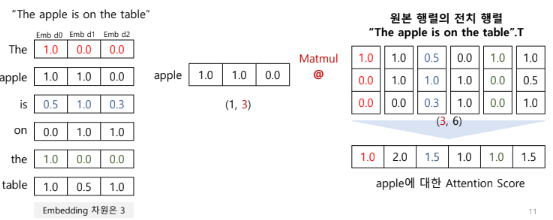

- pdf 2-1.transformer_핵심이해 -> 11p

In [89]:
# token 'apple'과 다른 토큰간의 attention score 계산하기
apple_query = token_embeddings[1]

apple_query
# QKV에서 Q

tensor([1., 1., 0.])

In [90]:
# 그대로 복사

keys = token_embeddings.clone()
keys

tensor([[1.0000, 0.0000, 0.0000],
        [1.0000, 1.0000, 0.0000],
        [0.5000, 1.0000, 0.3000],
        [0.0000, 1.0000, 1.0000],
        [1.0000, 0.0000, 0.0000],
        [1.0000, 0.5000, 1.0000]])

In [91]:
keys.T  # 내적하기위해 

tensor([[1.0000, 1.0000, 0.5000, 0.0000, 1.0000, 1.0000],
        [0.0000, 1.0000, 1.0000, 1.0000, 0.0000, 0.5000],
        [0.0000, 0.0000, 0.3000, 1.0000, 0.0000, 1.0000]])

In [92]:
# (1, 3) @ (3, 6) -> 내적(dot product)

# apple_attn_scores = apple_query @ token_embeddings.T 

apple_attn_scores = apple_query @ keys.T
apple_attn_scores # 1행 6열 나와야함 



tensor([1.0000, 2.0000, 1.5000, 1.0000, 1.0000, 1.5000])

# 단일 토큰에 대한 attention weights 계산하기

- attention score 값에 대해서 softmax로 정규화 적용(전체 sum이 1이 되도록 적용).
- embedding 차원 개수로의 scale 작업은 일단 수행하지 않음

In [93]:
# attention score 값에 대해서 softmax로 정규화 적용(전체 sum이 1이 되도록 적용). 
# embedding 차원 개수로의 scale 작업은 일단 수행하지 않음
# 1차원에 대한 softmax 적용이므로 dim이 불필요 할 수도 있지만, 
# 함수에서 명시적으로 설정할 것을 요구

import torch.nn.functional as F


reads_attn_weights = F.softmax(apple_attn_scores,dim = -1)
print(f"apple_attn_weights : {reads_attn_weights}")


# apple_attn_weights : tensor([0.1109, 0.3015, 0.1829, 0.1109, 0.1109, 0.1829])

apple_attn_weights : tensor([0.1109, 0.3015, 0.1829, 0.1109, 0.1109, 0.1829])


In [94]:
# softmax를 통과한 값의 합은 1

reads_attn_weights.sum()

tensor(1.)

# 단일 토큰의 context vector 값 구하기

- 개별 단어의 Attention Weights를 반영하여 문장 문맥 의미가 적용된 단어 만들기

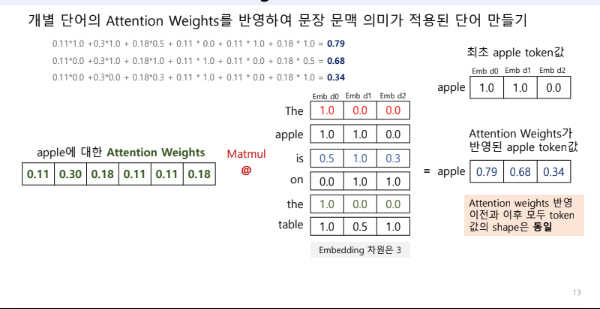

In [95]:
apple_query = token_embeddings[1]
# apple의 key

keys = token_embeddings.clone() # 전체에 대한 임베딩 값 
keys

tensor([[1.0000, 0.0000, 0.0000],
        [1.0000, 1.0000, 0.0000],
        [0.5000, 1.0000, 0.3000],
        [0.0000, 1.0000, 1.0000],
        [1.0000, 0.0000, 0.0000],
        [1.0000, 0.5000, 1.0000]])

In [96]:
# apple token의 context vector를 구하기 위한 values

values = token_embeddings.clone()
values

tensor([[1.0000, 0.0000, 0.0000],
        [1.0000, 1.0000, 0.0000],
        [0.5000, 1.0000, 0.3000],
        [0.0000, 1.0000, 1.0000],
        [1.0000, 0.0000, 0.0000],
        [1.0000, 0.5000, 1.0000]])

In [97]:
# apple의 attention weight 구하기

apple_attn_weight = F.softmax(apple_query @ keys.T, dim = -1) # dim = -1 이란 마지막 칼럼을 말함
print(f"apple_attn_weight: {apple_attn_weight}")


apple_attn_weight: tensor([0.1109, 0.3015, 0.1829, 0.1109, 0.1109, 0.1829])


In [98]:
# apple token의 context vector 값 구하기
# (1,8) @ (8,3)

apple_contex_vec = apple_attn_weight @ values
print(f"apple_context_vec: {apple_contex_vec}")

apple_context_vec: tensor([0.7976, 0.6867, 0.3487])


In [99]:
# 전체 query token들의 attention weights를 시뮬레이션하기 위해서
# 개별 query token들을 loop 방식으로 차례로 q @ K.T 적용

attn_weights_matrix_temp = torch.empty(token_embeddings.shape[0], token_embeddings.shape[0])
print(attn_weights_matrix_temp.shape)

torch.Size([6, 6])


In [100]:
queries = token_embeddings.clone()
keys = token_embeddings.clone()

#전체 token들을 순차적으로 loop를 돌면서 attention_weight를 구함
for idx, query_token in enumerate(queries):
    attn_weight = F.softmax(query_token @ keys.T,dim=-1)
    print(f"token {tokens[idx]}: {query_token}'s attn_weight: {attn_weight}")
    attn_weights_matrix_temp[idx] = attn_weight

print(f"\nattn_weights_matrix_temp:\n{attn_weights_matrix_temp}")


token The: tensor([1., 0., 0.])'s attn_weight: tensor([0.2010, 0.2010, 0.1219, 0.0740, 0.2010, 0.2010])
token apple: tensor([1., 1., 0.])'s attn_weight: tensor([0.1109, 0.3015, 0.1829, 0.1109, 0.1109, 0.1829])
token is: tensor([0.5000, 1.0000, 0.3000])'s attn_weight: tensor([0.0871, 0.2367, 0.2017, 0.1938, 0.0871, 0.1938])
token on: tensor([0., 1., 1.])'s attn_weight: tensor([0.0494, 0.1342, 0.1811, 0.3647, 0.0494, 0.2212])
token the: tensor([1., 0., 0.])'s attn_weight: tensor([0.2010, 0.2010, 0.1219, 0.0740, 0.2010, 0.2010])
token table: tensor([1.0000, 0.5000, 1.0000])'s attn_weight: tensor([0.0986, 0.1626, 0.1332, 0.1626, 0.0986, 0.3443])

attn_weights_matrix_temp:
tensor([[0.2010, 0.2010, 0.1219, 0.0740, 0.2010, 0.2010],
        [0.1109, 0.3015, 0.1829, 0.1109, 0.1109, 0.1829],
        [0.0871, 0.2367, 0.2017, 0.1938, 0.0871, 0.1938],
        [0.0494, 0.1342, 0.1811, 0.3647, 0.0494, 0.2212],
        [0.2010, 0.2010, 0.1219, 0.0740, 0.2010, 0.2010],
        [0.0986, 0.1626, 0.1332, 

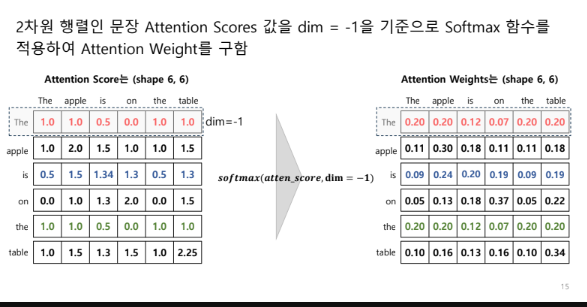

- 여기까지 진행한것 

# 문장내 모든 token들의 attention weights 구하기

- Q = token_embeddings, K = token_embeddings 일때

- Softmax(Q @ K.T) 로 문장내 모든 token들의 attention weights 계산(정방 행렬이 됨)

- 생성된 attention weights의 shape는 (문장 sequence length, 문장 sequence length)가 됨.

- 즉 위의 token_embeddings는 6개의 token들(문장 sequence length가 6)로 구성되어 있으므로 attention weights의 shape는 (6, 6)

In [101]:
# matrix multiplication으로 모든 token들의 attention weight를 matrix 형태로 구하기
queries = token_embeddings.clone()
keys = token_embeddings.clone()

# attention score 계산
attn_scores = queries @ keys.T
# softmax 정규화 적용. dim = -1
attn_weights = F.softmax(attn_scores, dim=-1)

print(f"attn_scores:\n{attn_scores}")
print(f"attn_weights:\n{attn_weights}")

attn_scores:
tensor([[1.0000, 1.0000, 0.5000, 0.0000, 1.0000, 1.0000],
        [1.0000, 2.0000, 1.5000, 1.0000, 1.0000, 1.5000],
        [0.5000, 1.5000, 1.3400, 1.3000, 0.5000, 1.3000],
        [0.0000, 1.0000, 1.3000, 2.0000, 0.0000, 1.5000],
        [1.0000, 1.0000, 0.5000, 0.0000, 1.0000, 1.0000],
        [1.0000, 1.5000, 1.3000, 1.5000, 1.0000, 2.2500]])
attn_weights:
tensor([[0.2010, 0.2010, 0.1219, 0.0740, 0.2010, 0.2010],
        [0.1109, 0.3015, 0.1829, 0.1109, 0.1109, 0.1829],
        [0.0871, 0.2367, 0.2017, 0.1938, 0.0871, 0.1938],
        [0.0494, 0.1342, 0.1811, 0.3647, 0.0494, 0.2212],
        [0.2010, 0.2010, 0.1219, 0.0740, 0.2010, 0.2010],
        [0.0986, 0.1626, 0.1332, 0.1626, 0.0986, 0.3443]])


# Attention Weights 시각화

In [102]:
#uv add seaborn

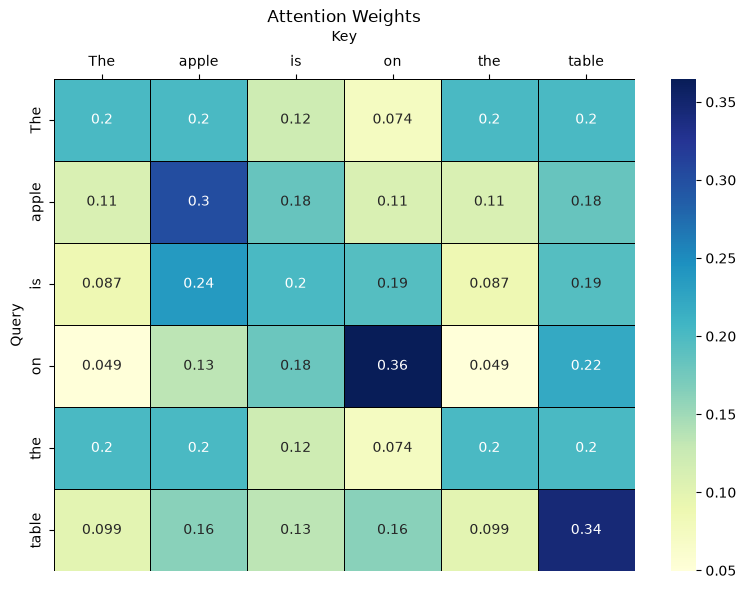

In [103]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt

tokens = ['The', 'apple', 'is', 'on', 'the', 'table']

plt.figure(figsize=(8, 6))
# 위에서 계산한 attn_weights를 numpy()를 변환하여 seaborn의 heatmap으로 시각화
ax = sns.heatmap(attn_weights.detach().numpy(), annot=True, 
                 cmap="YlGnBu", xticklabels=tokens, yticklabels=tokens,
                linewidths=0.5, linecolor='black')

# Title and labels
plt.title("Attention Weights")
ax.set_xlabel("Key", labelpad=10)
ax.set_ylabel("Query")

# Move xlabel and xticklabels to top
ax.xaxis.set_label_position("top")
ax.xaxis.tick_top()

plt.tight_layout()
plt.show()

# 전체 토큰의 context vector 값 구하기
- 문장 문맥이 반영된 전체 토큰들의 context vector들은
attention weights @ V(여기서 V는 전체 토큰들 = token_embeddings) 구할 수 있음

In [107]:
# 모든 token들에 대한 context vector들을 matrix multiplication으로 구하기

queries = token_embeddings.clone()
keys = token_embeddings.clone()
values = token_embeddings.clone()

attn_weights = F.softmax(queries @ keys.T, dim = -1)
print(f"attn_weight : \n{attn_weights}")

attn_weight : 
tensor([[0.2010, 0.2010, 0.1219, 0.0740, 0.2010, 0.2010],
        [0.1109, 0.3015, 0.1829, 0.1109, 0.1109, 0.1829],
        [0.0871, 0.2367, 0.2017, 0.1938, 0.0871, 0.1938],
        [0.0494, 0.1342, 0.1811, 0.3647, 0.0494, 0.2212],
        [0.2010, 0.2010, 0.1219, 0.0740, 0.2010, 0.2010],
        [0.0986, 0.1626, 0.1332, 0.1626, 0.0986, 0.3443]])


In [108]:

# attention weight와 values의 내적으로 context vector를 구함.
context_vecs = attn_weight @ values
print(f"context_vecs : \n{context_vecs}")




context_vecs : 
tensor([0.7708, 0.6306, 0.5469])


# Self Attention
학습 파라미터가 적용된 Query, Key, Value
- 입력 token embedding tensor만으로 구성된 query, key, value tensor 각각에 학습 파라미터(Learnable Parameter)를 부여하여 선형 변환하고 이를 이용하여 attention weights 및 context vector를 구함
    - Q = X @ Wq
    - K = X @ Wk
    - V = X @ Wv
- 일반적으로 Q, K , V 의 Shape는 모두 입력 tensor(여기서는 X)의 Shape와 동일.
- attention shape는 (seq_len, seq_len)
- context vector의 shape는 입력 tensor(여기서는 X)의 Shape와 동일
- 여기서는 입력 tensor의 shape를 (seq_len, emb_dim)인 2차원 shape로 가정. 실제 문장들은 여러개의 문장이 입력되므로 batch size를 감안하여 (batch_size, seq_len, emb_dim)이 입력됨.

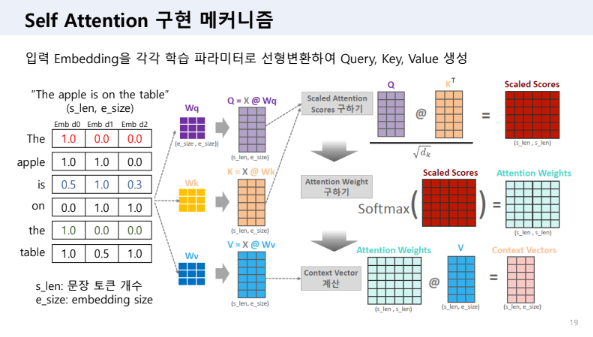


여기서 학습 대상은? (weight ) -> wq , wk , wv


In [106]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:

tokens = ['The', 'apple', 'is', 'on', 'the', 'table']

# 테스트용 값으로 token embeddings tensor 값 생성.
token_embeddings = torch.tensor([
    [1.0, 0.0, 0.0],   # The
    [1.0, 1.0, 0.0],   # apple
    [0.5, 1.0, 0.5],   # is
    [0.0, 1.0, 1.0],   # on
    [1.0, 0.0, 0.0],   # the
    [1.0, 0.5, 1.0],   # table
])  # shape: (6, 3)

seq_len = token_embeddings.shape[0] # 문장 토큰 개수
emb_dim = token_embeddings.shape[1] # embedding size 
print(f"seq_len:{seq_len}, emb_dim:{emb_dim}")



seq_len:6, emb_dim:3


# nn.Linear로 Wq, Wk, Wv를 token embedding에 적용

In [110]:
sample_linear = nn.Linear(in_features=3, out_features=3, bias=False)
sample_linear.weight.shape

torch.Size([3, 3])

In [ ]:
import torch
import torch.nn as nn

torch.manual_seed(2026)
linear_q = nn.Linear(in_features=emb_dim, out_features=emb_dim, bias=False)
linear_k = nn.Linear(in_features=emb_dim, out_features=emb_dim, bias=False)
linear_v = nn.Linear(in_features=emb_dim, out_features=emb_dim, bias=False)

query = linear_q(token_embeddings)
key = linear_k(token_embeddings)
value = linear_v(token_embeddings)

print(f"linear_q learnable parameter shape: {linear_q.weight.shape}")
print(f"query shape: {query.shape} \nquery: {query}")
print(f"key shape: {key.shape} \nkey: {key}")
print(f"value shape: {value.shape} \nvalue: {value}")


attention scores와 attention weights 계산
- attention scores 계산 시 embedding dim의 루트값으로 나누는 scale 적용

In [ ]:
import math

scale = math.sqrt(emb_dim)
# scale = emb_dim ** 0.5
print(f"emb_dim: {emb_dim}")
print(f"scale: {scale}") 

In [ ]:
#  attention scores 계산 시 embedding dim의 루트값으로 나누는 scale 적용
attention_scores = query @ key.transpose(0, 1) / scale # key.T
print(f"attention_scores:\n{attention_scores}\nattention_scores shape:{attention_scores.shape}")

attention_weights = F.softmax(attention_scores, dim=-1)
print(f"attention_weights:\n{attention_weights}\nattention_weights shape:{attention_weights.shape}")

scaled dot product 적용 테스트
- 입력 embedding 차원이 클 수록 dot product 값이 커짐.

- softmax 값이 매우 sharp(표준 편차가 커짐)하게 되면서 특정 토큰에 attention이 집중되는 현상 발생\

- 학습시 Gradient값이 매우 불안정하게 됨

- 입력 embedding 차원 수의 제곱근으로 scale 적용시 보다 안정적으로 attention score/weights가 생성되며 안정된 학습 가능

In [ ]:
# attention weights와 attention scores 계산 함수 정의
def do_test_with_scale(embeddings, use_scale = True):
    seq_len = embeddings.shape[0]
    emb_dim = embeddings.shape[1]

    torch.manual_seed(2026)
    linear_q = nn.Linear(in_features=emb_dim, out_features=emb_dim, bias=False)
    linear_k = nn.Linear(in_features=emb_dim, out_features=emb_dim, bias=False)
    linear_v = nn.Linear(in_features=emb_dim, out_features=emb_dim, bias=False)

    query = linear_q(embeddings)
    key = linear_k(embeddings)
    value = linear_v(embeddings)

    scale = math.sqrt(emb_dim) if use_scale else 1.0  # use_scale이 False이면 scale 적용하지 않음
    attention_scores = query @ key.transpose(0, 1) / scale # key.T
    attention_weights = F.softmax(attention_scores, dim=-1)

    return attn_weights, attention_scores
    

In [ ]:
#
torch.manual_seed(2026)

emb_dims = [16, 256] # embedding 크기 변화하면서 테스트하기
seq_len = 100
for emb_dim in emb_dims :
    embeddings = torch.randn(seq_len, emb_dim)
    for scale_option in [False, True]: # use_scale True/False 인 경우 테스트
        print(f"\n#### embeddings dim size:{embeddings.shape[-1]} scale_option={scale_option}")
        attn_weights, attn_scores = do_test_with_scale(embeddings, use_scale=scale_option)
        print("Scores mean:", attn_scores.mean().item(), "std:", attn_scores.std().item())
        print("Scores max:", attn_scores.max().item(), "min:", attn_scores.min().item())
        print("Attn weights mean:", attn_weights.mean().item(), "std:", attn_weights.std().item())
        print("Attn weights max:", attn_weights.max().item(), "min:", attn_weights.min().item())

# Self Attention 모듈화 구현

- 3차원 입력(batch_size, seq_len, emb_dim)을 가정하여 구현
- attention weights에 dropout 적용

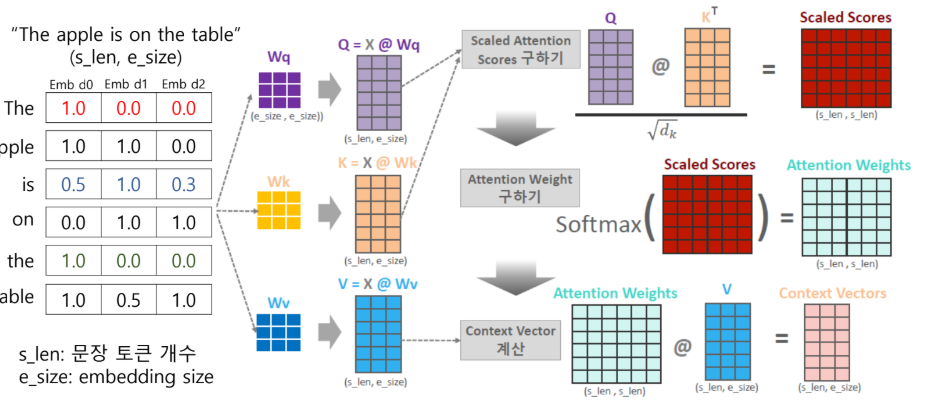

In [ ]:
import math

class SelfAttention_1th(nn.Module):
    def __init__(self, emb_dim, dropout=0.1):
        super().__init__()

        self.linear_q = nn.Linear(emb_dim, emb_dim) # bias = True
        self.linear_k = nn.Linear(emb_dim,emb_dim) # bias = True
        self.linear_v = nn.Linear(emb_dim,emb_dim) # bias = True

        self.scale = math.sqrt(emb_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self,x):
        query = self.linear_q(x)
        key = self.linear_k(x)
        value = self.linear_v(x)

        #key는 batch가 아닌 1,2차원이 서로 transpose 해야함 
        #key.transpose(-2,-1)
        scores = torch.matmul(query,key.transpose(1,2) / self.scale)
        # attention weights에 dropout 적용
        attn_weights = self.dropout(attn_weights)

        # context vector 생성
        context = torch.matmul(attn_weights,value)

        return context, attn_weights
    



In [111]:
batch_size = 8
seq_len = 100
emb_dim = 128

sample_token_embedding = torch.randn((batch_size, seq_len,emb_dim))
print(f"sample_token_embedding.shape: {sample_token_embedding.shape}")

sample_token_embedding.shape: torch.Size([8, 100, 128])


In [112]:
self_attention = SelfAttention_1th(emb_dim,dropout=0.1)
context, attn_weights = self_attention(sample_token_embedding)

#atten_weight의 shape는 (batch_size,seq_len,seq_len)
#context의 shape는 (batch_size,seq_len,emb_dim)
print(f"attn_weights shape: {attn_weights.shape}\ncontext shape : {context.shape}")

attn_weights shape: torch.Size([8, 100, 100])
context shape : torch.Size([8, 100, 128])
